# 4. Metodología y desarrollo

**Clasificación del sentimiento en evaluaciones de artículos científicos en español.** Se compara aprendizaje supervisado con TF-IDF y tres algoritmos. La práctica predice el tono del comentario; no determina la calidad científica ni la aceptación del artículo.

Ejecute **Restart Kernel and Run All Cells** la primera vez. Para la demo posterior, modifique únicamente mi_evaluacion en la celda 23.

**Ejecución observada:** 382 comentarios españoles; 307 de entrenamiento y 75 de prueba, con artículos separados. Linear SVM se seleccionó por F1 macro CV. En prueba obtuvo Accuracy 46.67% y F1 macro 0.3877. El reconocimiento de neutrales es limitado; revise el informe por clase y los errores.

## 4.1 Dataset y etiquetado

Se utiliza [Paper Reviews, UCI](https://archive.ics.uci.edu/dataset/410/paper+reviews), Brian Keith (2017), DOI [10.24432/C50G60](https://doi.org/10.24432/C50G60). El corpus contiene 405 evaluaciones, mayoritariamente en español. La derivación española conserva el campo text y la orientación anotada, con atribución y licencia CC BY 4.0. Consulte data/README.md y data/ATTRIBUTION.md.

### Celda 1. Configurar el entorno

**Objetivo:** preparar las herramientas, las rutas y las opciones que utilizarán las demás celdas. Esta celda todavía no carga datos ni entrena modelos.

- Los `import` permiten usar librerías ya instaladas. `pandas` (`pd`) maneja tablas; `numpy` (`np`) realiza operaciones numéricas; `matplotlib.pyplot` (`plt`) dibuja gráficos. Las herramientas de `sklearn` permiten dividir datos, convertir texto en números, entrenar y evaluar.
- `Path` maneja rutas; `json` lee y guarda metadatos; `hashlib` calcula huellas de archivos. `re`, `html` y `unicodedata` se usarán para limpiar texto. `time` mide duración y `datetime` registra la fecha de ejecución.
- `SEMILLA = 42` fija la referencia aleatoria para repetir las particiones con los mismos datos y versiones. No es una puntuación del modelo. `N_JOBS = 2` permite hasta dos trabajos paralelos en la búsqueda.
- `CLASES` fija el orden **negativo, neutral, positivo** en las tablas y matrices.
- `RAIZ` busca la carpeta del proyecto comprobando que existe `scripts/descargar_dataset.py`. `SALIDA` apunta a `resultados/`; `mkdir(exist_ok=True)` crea esa carpeta si falta.
- `versiones` registra las versiones instaladas. `plt.rcParams.update(...)` configura el tamaño y la apariencia de los gráficos; `pd.set_option(...)` limita cuánto texto muestra una tabla.

**Salida:** las versiones de las librerías. Si aparece `FileNotFoundError`, abra Jupyter desde la carpeta del proyecto o desde `notebooks/`.

In [1]:
# Celda 1: importar y configurar
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version
import hashlib
import html
import json
import os
import re
import time
import unicodedata
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from joblib import parallel_backend
from threadpoolctl import threadpool_limits
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

SEMILLA = 42
N_JOBS = 2
CLASES = ["negativo", "neutral", "positivo"]
candidatos = [Path.cwd(), Path.cwd().parent, Path.cwd() / "sentimiento-academico"]
RAIZ = next((p for p in candidatos if (p / "scripts" / "descargar_dataset.py").exists()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra el notebook desde la carpeta del proyecto o notebooks/.")
SALIDA = RAIZ / "resultados"
SALIDA.mkdir(exist_ok=True)
versiones = {p: version(p) for p in ["pandas", "numpy", "scikit-learn", "matplotlib"]}
plt.rcParams.update({"figure.figsize": (8, 4.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 110})
pd.set_option("display.max_colwidth", 90)
print("Versiones:", versiones)

Versiones: {'pandas': '3.0.6', 'numpy': '2.5.3', 'scikit-learn': '1.9.1', 'matplotlib': '3.11.2'}


### Celda 2. Cargar el dataset español

**Objetivo:** obtener una tabla verificable de evaluaciones académicas en español a partir del archivo original de UCI.

1. `ruta_dataset` identifica `data/articulos_es.csv`. `subprocess.run(...)` ejecuta el script de preparación con `sys.executable`, el mismo Python que usa este notebook. El script verifica el JSON original y reconstruye el CSV; descarga el original únicamente si falta.
2. `check=True` detiene la ejecución si el script falla. `capture_output=True` recoge sus mensajes y `encoding="utf-8"` permite leer correctamente tildes y ñ.
3. `json.loads(...)` carga `source.json`, que registra la procedencia. SHA-256 calcula una huella del CSV y `assert` comprueba que coincide con la registrada. Esta comprobación detecta cambios en el archivo; no demuestra por sí sola que sus etiquetas sean correctas.
4. `pd.read_csv(..., keep_default_na=False)` carga el CSV como una tabla llamada `df_original`. Conserva cadenas vacías para contarlas antes de excluirlas. Otra comprobación exige que todos los registros tengan `idioma = "es"`.
5. `auditoria` empieza a registrar los conteos del proceso. `head(5)` muestra solo cinco filas; `str.len()` añade su longitud en caracteres a la vista.

**Salida:** 388 evaluaciones en español de las 405 originales. Todavía se incluyen seis comentarios vacíos. Los 17 comentarios en inglés no se traducen ni se utilizan.

In [2]:
# Celda 2: cargar las evaluaciones originales en español
ruta_dataset = RAIZ / "data" / "articulos_es.csv"
preparacion = subprocess.run(
    [sys.executable, str(RAIZ / "scripts" / "descargar_dataset.py")], check=True,
    capture_output=True, text=True, encoding="utf-8",
    env={**os.environ, "PYTHONUTF8": "1", "PYTHONIOENCODING": "utf-8"},
)
print(preparacion.stdout.strip())
procedencia = json.loads((RAIZ / "data" / "source.json").read_text(encoding="utf-8"))
sha256 = hashlib.sha256(ruta_dataset.read_bytes()).hexdigest()
assert sha256 == procedencia["sha256_csv_derivado"], "El CSV cambió respecto de source.json."
df_original = pd.read_csv(ruta_dataset, keep_default_na=False)
assert df_original["idioma"].eq("es").all()
auditoria = {"filas_origen": procedencia["estadisticas"]["evaluaciones_originales"], "filas_espanol": len(df_original)}
print("Fuente: Paper Reviews, UCI; DOI 10.24432/C50G60")
print("Evaluaciones en español:", len(df_original))
display(df_original[["articulo_id", "evaluacion_id", "orientacion", "idioma"]].assign(
    caracteres=df_original["texto"].str.len()
).head(5))

Paper Reviews verificado: 405 evaluaciones originales.
CSV español: 388 evaluaciones; 6 con texto vacío.
SHA-256 CSV: 12cae78bbc1b73c852c70bde718dabc4ec9bc09969c97e50203ab0707698b81b
El notebook aplica las exclusiones y utiliza únicamente texto para predecir.
Fuente: Paper Reviews, UCI; DOI 10.24432/C50G60
Evaluaciones en español: 388


,articulo_id,evaluacion_id,orientacion,idioma,caracteres
0,1,1,0,es,575
1,1,2,1,es,618
2,1,3,1,es,1259
3,2,1,1,es,1350
4,2,2,0,es,0


### Celda 3. Revisar el esquema

**Objetivo:** comprobar que la tabla tiene las columnas y los identificadores necesarios antes de modificarla.

- Un **DataFrame** es una tabla de filas y columnas. Aquí cada fila representa una evaluación escrita sobre un artículo; un artículo puede recibir varias evaluaciones.
- `issubset(df_original)` exige las columnas `articulo_id`, `evaluacion_id`, `texto`, `orientacion` e `idioma`. Un `assert` detiene la ejecución si la condición no se cumple.
- `duplicated(["articulo_id", "evaluacion_id"])` busca pares de identificadores repetidos. `any()` pregunta si existe al menos uno y `not` exige que no exista ninguno.
- `evaluacion_id` identifica una evaluación dentro de su artículo. Por eso se verifica junto con `articulo_id`, no como identificador global independiente.
- `dtypes` muestra el tipo de cada columna. `rename("tipo").to_frame()` presenta esos tipos como una tabla legible.

**Salida:** la tabla de tipos. Esta revisión ayuda a detectar un archivo con una estructura distinta a la esperada.

In [3]:
# Celda 3: revisar el esquema y la unidad de observación
assert {"articulo_id", "evaluacion_id", "texto", "orientacion", "idioma"}.issubset(df_original)
assert not df_original.duplicated(["articulo_id", "evaluacion_id"]).any()
print("Cada fila es una evaluación; cada artículo puede tener varias evaluaciones.")
display(df_original.dtypes.rename("tipo").to_frame())

Cada fila es una evaluación; cada artículo puede tener varias evaluaciones.


,tipo
articulo_id,int64
evaluacion_id,int64
texto,str
orientacion,int64
idioma,str
fecha,str
anio,int64


### Celda 4. Elegir texto, etiqueta y grupo

**Objetivo:** separar la información que el modelo debe aprender de la información usada para etiquetar y organizar los datos.

| Columna conservada | Uso en la práctica |
| --- | --- |
| `texto` | Única entrada del clasificador; procede de `text` en el original. |
| `orientacion` | Genera la respuesta esperada; procede de `orientation`. |
| `articulo_id` | Mantiene juntas las evaluaciones del mismo artículo al dividir los datos. |
| `evaluacion_id` | Permite localizar y revisar una evaluación concreta. |

`df_original[[...]].copy()` crea la tabla de trabajo `df` con esas cuatro columnas. `.copy()` permite modificarla sin alterar la tabla original.

**Por qué importa:** entregar la orientación al modelo como entrada revelaría la respuesta que debe predecir. `evaluation` es la valoración del revisor y puede diferir del sentimiento anotado. Tampoco se usan la decisión editorial, la confianza ni `remarks` como características.

**Salida:** una vista de los identificadores y la orientación. El objetivo es clasificar el sentimiento del comentario, no decidir si el artículo debe aceptarse.

In [4]:
# Celda 4: conservar texto, etiqueta y grupo
df = df_original[["articulo_id", "evaluacion_id", "texto", "orientacion"]].copy()
print("Solo texto será entrada del clasificador.")
print("orientation genera la etiqueta; articulo_id sirve solo para separar grupos.")
print("evaluation, decisión editorial, confianza y remarks no se usan.")
display(df[["articulo_id", "evaluacion_id", "orientacion"]].head(5))

Solo texto será entrada del clasificador.
orientation genera la etiqueta; articulo_id sirve solo para separar grupos.
evaluation, decisión editorial, confianza y remarks no se usan.


,articulo_id,evaluacion_id,orientacion
0,1,1,0
1,1,2,1
2,1,3,1
3,2,1,1
4,2,2,0


### Celda 5. Excluir comentarios vacíos

**Objetivo:** conservar evaluaciones que tengan texto y una orientación válida.

1. `isna().any(axis=1).sum()` cuenta filas con algún valor nulo y registra el resultado en `auditoria`. Un valor nulo representa información ausente; una cadena vacía puede existir sin ser nula.
2. `dropna(subset=[...])` excluye filas sin texto, orientación o identificador de artículo.
3. `str.strip().eq("")` detecta textos vacíos, incluso si solo tienen espacios. La variable `vacios` contiene un valor verdadero o falso para cada fila.
4. `df.loc[~vacios]` conserva las filas que no están vacías. `~` invierte esa selección.
5. `pd.to_numeric(..., errors="raise").astype(int)` convierte la orientación a enteros y falla si encuentra un valor no convertible. `isin([-2, -1, 0, 1, 2])` comprueba su dominio permitido.

**Salida:** seis textos vacíos excluidos y 382 evaluaciones no vacías. Los conteos quedan registrados para justificar el tamaño final del conjunto.

In [5]:
# Celda 5: excluir valores faltantes y comentarios vacíos
auditoria["filas_con_nulos"] = int(df.isna().any(axis=1).sum())
df = df.dropna(subset=["texto", "orientacion", "articulo_id"]).copy()
vacios = df["texto"].str.strip().eq("")
auditoria["textos_vacios_originales"] = int(vacios.sum())
df = df.loc[~vacios].copy()
df["orientacion"] = pd.to_numeric(df["orientacion"], errors="raise").astype(int)
assert df["orientacion"].isin([-2, -1, 0, 1, 2]).all()
print("Textos vacíos excluidos:", auditoria["textos_vacios_originales"])
print("Evaluaciones no vacías:", len(df))

Textos vacíos excluidos: 6
Evaluaciones no vacías: 382


### Celda 6. Revisar duplicados

**Objetivo:** evitar que copias idénticas del mismo texto con la misma orientación se cuenten como observaciones diferentes.

`duplicated(["texto", "orientacion"]).sum()` cuenta las repeticiones del par. `drop_duplicates(...)` conserva la primera aparición de cada par. `reset_index(drop=True)` renumera las filas sin añadir una columna con el índice anterior.

Esta revisión exige que coincidan tanto el texto original como la orientación. Diferencias de mayúsculas o puntuación pueden ocultar repeticiones; por eso la celda 9 revisa otra vez el texto después de limpiarlo. También comprueba allí si un mismo texto limpio tiene etiquetas contradictorias.

**Salida:** cero duplicados de este tipo en los datos utilizados y 382 evaluaciones conservadas. El código mantiene la comprobación aunque en esta ejecución no retire ninguna fila.

In [6]:
# Celda 6: revisar duplicados exactos
auditoria["duplicados_pares"] = int(df.duplicated(["texto", "orientacion"]).sum())
df = df.drop_duplicates(["texto", "orientacion"]).reset_index(drop=True)
auditoria["filas_tras_4_1"] = len(df)
print("Duplicados de texto y orientación:", auditoria["duplicados_pares"])
print("Evaluaciones conservadas:", len(df))

Duplicados de texto y orientación: 0
Evaluaciones conservadas: 382


### Celda 7. Construir las tres etiquetas

**Objetivo:** convertir cinco niveles de orientación en las tres clases que aprenderá el clasificador.

| Orientación original | Etiqueta creada |
| --- | --- |
| −2 o −1 | `negativo` |
| 0 | `neutral` |
| 1 o 2 | `positivo` |

`def etiquetar_sentimiento(orientacion):` define una función. Los bloques `if` revisan el valor recibido y `return` devuelve su etiqueta. `raise ValueError(...)` detiene el proceso si llega un valor fuera del dominio permitido.

`apply(etiquetar_sentimiento)` aplica la función a cada orientación y crea la columna `sentimiento`. Un `assert` comprueba que están presentes las tres clases. `pd.crosstab(...)` cruza orientación y sentimiento para comprobar visualmente el mapeo; `reindex(columns=CLASES)` ordena las columnas.

**Interpretación:** las etiquetas proceden de la anotación original, no de buscar palabras positivas o negativas. Agrupar los niveles pierde información sobre intensidad; un comentario mixto puede haber sido anotado como neutral.

In [7]:
# Celda 7: agrupar la orientación anotada en tres sentimientos
def etiquetar_sentimiento(orientacion):
    if orientacion in (-2, -1):
        return "negativo"
    if orientacion == 0:
        return "neutral"
    if orientacion in (1, 2):
        return "positivo"
    raise ValueError("Orientación fuera del intervalo permitido.")
df["sentimiento"] = df["orientacion"].apply(etiquetar_sentimiento)
assert set(df["sentimiento"]) == set(CLASES)
display(pd.crosstab(df["orientacion"], df["sentimiento"]).reindex(columns=CLASES, fill_value=0))

sentimiento,negativo,neutral,positivo
orientacion,,,
-2,35,0,0
-1,137,0,0
0,0,104,0
1,0,0,91
2,0,0,15


### Celda 8. Mostrar la distribución

**Objetivo:** conocer cuántas evaluaciones hay de cada sentimiento antes de entrenar.

- `value_counts()` cuenta las etiquetas. `reindex(CLASES)` mantiene el mismo orden en todas las salidas.
- `distribucion` reúne los conteos y sus porcentajes. Cada porcentaje se calcula como **conteo de la clase / número total de evaluaciones × 100**. `round(2)` redondea solo la presentación.
- `to_csv(...)` guarda la tabla. `barh(...)` crea barras horizontales; `bar_label(...)` añade cantidades y porcentajes. `savefig(...)` guarda el gráfico y `plt.show()` lo muestra en el notebook.
- `display(Markdown(...))` presenta una interpretación calculada desde los datos.

**Salida:** 172 negativos, 104 neutrales y 106 positivos. Los negativos son la clase más frecuente. Una Accuracy aceptable puede ocultar errores en otras clases; por eso después se revisan F1 macro y métricas por clase.

**Archivos:** `distribucion_4_1.csv` y `distribucion_clases.png` en `resultados/`.

sentimiento
negativo    172
positivo    106
neutral     104
Name: count, dtype: int64


,evaluaciones,porcentaje
sentimiento,,
negativo,172,45.03
neutral,104,27.23
positivo,106,27.75


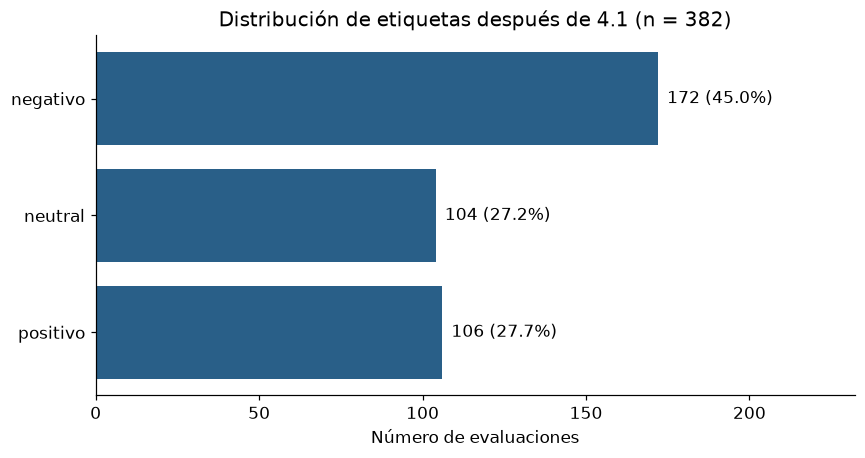

La clase positiva representa **27.75%** de las evaluaciones conservadas en 4.1. Se evaluarán las tres clases por separado.

In [8]:
# Celda 8: distribución antes de normalizar el texto
print(df["sentimiento"].value_counts())
conteos_4_1 = df["sentimiento"].value_counts().reindex(CLASES)
distribucion = pd.DataFrame({"evaluaciones": conteos_4_1,
                            "porcentaje": conteos_4_1 / len(df) * 100})
display(distribucion.round(2))
distribucion.to_csv(SALIDA / "distribucion_4_1.csv", index_label="sentimiento")
fig, ax = plt.subplots(figsize=(8, 4.3))
barras = ax.barh(CLASES, conteos_4_1.values, color="#295F88")
ax.bar_label(barras, labels=[f"{n:,} ({n / len(df):.1%})" for n in conteos_4_1], padding=6)
ax.set_xlim(0, conteos_4_1.max() * 1.35)
ax.set_xlabel("Número de evaluaciones")
ax.set_title(f"Distribución de etiquetas después de 4.1 (n = {len(df):,})")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(SALIDA / "distribucion_clases.png", dpi=160)
plt.show()
display(Markdown(f"La clase positiva representa **{distribucion.loc['positivo', 'porcentaje']:.2f}%** "
                 "de las evaluaciones conservadas en 4.1. Se evaluarán las tres clases por separado."))

## 4.2 Limpieza y vectorización

El mismo preprocesamiento se usa para entrenamiento y para nuevos comentarios. El vectorizador se ajusta después de la partición y dentro de cada Pipeline de validación.

### Celda 9. Limpiar el texto español

**Objetivo:** representar de forma consistente los comentarios sin borrar las tildes, la ñ ni las negaciones.

La función `limpiar_texto(texto)` realiza estos pasos en orden:

1. `str(texto)` convierte la entrada a texto. `html.unescape(...)` convierte entidades HTML en caracteres; por ejemplo, `&amp;` pasa a `&`.
2. `unicodedata.normalize("NFC", ...)` unifica representaciones Unicode equivalentes de letras acentuadas. `.lower()` convierte las mayúsculas a minúsculas.
3. `re.sub(...)` sustituye etiquetas HTML y enlaces por espacios. Las expresiones regulares describen los patrones que se eliminan.
4. `isalpha()` conserva letras, incluidas ñ y vocales acentuadas. `isspace()` conserva espacios. Los demás caracteres se sustituyen por espacios: se retiran números y puntuación.
5. La última expresión regular reduce espacios repetidos a uno y `.strip()` retira los de los extremos. `return` entrega el texto limpio.

`apply(limpiar_texto)` crea `texto_limpio`. Después se excluyen textos que quedaron vacíos y se cuentan repeticiones y etiquetas contradictorias. `groupby(...).nunique().gt(1)` detecta si un mismo texto limpio tiene más de una etiqueta. La eliminación de duplicados conserva la primera aparición; en esta ejecución no hay conflictos ni duplicados normalizados, y permanecen 382 evaluaciones.

Los `assert` comprueban ejemplos concretos y que `no` no desaparezca. La tabla usa frases redactadas para mostrar el antes y el después; esas frases no se añaden al entrenamiento.

**Límite:** la limpieza pierde cifras y puntuación, que también pueden expresar significado. No se aplica stemming ni lematización. TF-IDF se configura después de separar los datos.

In [9]:
# Celda 9: limpiar español y evitar textos repetidos entre particiones
def limpiar_texto(texto):
    texto = unicodedata.normalize("NFC", html.unescape(str(texto))).lower()
    texto = re.sub(r"<[^>]+>", " ", texto)
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = "".join(c if c.isalpha() or c.isspace() else " " for c in texto)
    return re.sub(r"\s+", " ", texto).strip()

df["texto_limpio"] = df["texto"].apply(limpiar_texto)
auditoria["textos_vacios_limpieza"] = int(df["texto_limpio"].eq("").sum())
df = df.loc[df["texto_limpio"].ne("")].copy()
conflictos = df.groupby("texto_limpio")["sentimiento"].nunique().gt(1)
auditoria["textos_con_etiquetas_contradictorias"] = int(conflictos.sum())
auditoria["duplicados_texto_limpio"] = int(df.duplicated("texto_limpio").sum())
df = df.drop_duplicates("texto_limpio", keep="first").reset_index(drop=True)
auditoria["filas_modelado"] = len(df)
assert df["texto_limpio"].is_unique
assert limpiar_texto("La investigación no explica el método") == "la investigación no explica el método"
assert "no" in limpiar_texto("No demuestra").split()
assert limpiar_texto("no demuestra") != limpiar_texto("demuestra")
print(json.dumps(auditoria, indent=2, ensure_ascii=False))
# Ejemplos redactados para explicar la limpieza; no son filas del corpus.
ejemplos_limpieza = [
    "¡El artículo presenta un método CLARO y una contribución útil!",
    "La investigación no explica el método. https://ejemplo.com",
    "<p>El análisis no es suficiente; faltan 3 experimentos.</p>",
]
display(pd.DataFrame({"ejemplo_redactado": ejemplos_limpieza,
                      "texto_limpio": [limpiar_texto(t) for t in ejemplos_limpieza]}))

{
  "filas_origen": 405,
  "filas_espanol": 388,
  "filas_con_nulos": 0,
  "textos_vacios_originales": 6,
  "duplicados_pares": 0,
  "filas_tras_4_1": 382,
  "textos_vacios_limpieza": 0,
  "textos_con_etiquetas_contradictorias": 0,
  "duplicados_texto_limpio": 0,
  "filas_modelado": 382
}


,ejemplo_redactado,texto_limpio
0,¡El artículo presenta un método CLARO y una contribución útil!,el artículo presenta un método claro y una contribución útil
1,La investigación no explica el método. https://ejemplo.com,la investigación no explica el método
2,<p>El análisis no es suficiente; faltan 3 experimentos.</p>,el análisis no es suficiente faltan experimentos


## 4.3 Partición

Se evalúa el reconocimiento de sentimiento en comentarios de **artículos que no participaron en el entrenamiento**. La separación agrupada reduce el riesgo de compartir vocabulario específico del mismo artículo entre conjuntos.

### Celda 10. Definir entradas, etiquetas y grupos

**Objetivo:** preparar tres variables alineadas para dividir y entrenar.

| Variable | Contenido | Función |
| --- | --- | --- |
| `X` | Columna `texto_limpio` | Comentarios que recibe el clasificador. |
| `y` | Columna `sentimiento` | Etiquetas conocidas con las que aprende y se evalúa. |
| `grupos` | Columna `articulo_id` | Impide repartir un mismo artículo entre conjuntos. |

Cada variable es una **Series** de pandas: una columna con un índice que identifica sus filas. Las tres proceden de `df`, por lo que cada texto sigue asociado a su etiqueta y artículo.

`len(X)` cuenta evaluaciones; `grupos.nunique()` cuenta artículos distintos. Son cantidades diferentes porque un artículo puede tener varias evaluaciones.

**Salida:** 382 evaluaciones de 168 artículos. Los identificadores organizan la separación; no se convierten en características del clasificador.

In [10]:
# Celda 10: definir el texto, el sentimiento y el artículo
X = df["texto_limpio"]
y = df["sentimiento"]
grupos = df["articulo_id"]
print("Evaluaciones:", len(X), "| Artículos:", grupos.nunique())

Evaluaciones: 382 | Artículos: 168


### Celda 11. Separar por artículo

**Objetivo:** reservar una prueba con artículos que no aparezcan durante el entrenamiento.

`StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)` organiza cinco pliegues. Mantiene juntas las filas del mismo artículo e intenta conservar las proporciones de las clases, hasta donde lo permite esa agrupación. `shuffle=True` y la semilla hacen reproducible la aleatoriedad utilizada por el separador.

`split(X, y, groups=grupos)` produce pares de posiciones de entrenamiento y evaluación. `next(...)` toma siempre el **primer** par: aproximadamente cuatro quintas partes para entrenamiento y una quinta parte para prueba. No se prueba cada pliegue para quedarse con el de mejores métricas.

`.iloc[indices_train]` y `.iloc[indices_test]` seleccionan las filas por posición. Se aplican los mismos índices al texto, las etiquetas y los grupos para mantener su correspondencia.

Los `assert` comprueban que no hay artículos ni textos limpios compartidos, que ninguna fila se pierde y que ambos conjuntos contienen las tres clases. La tabla presenta sus conteos.

**Salida:** 307 evaluaciones de 132 artículos para entrenamiento y 75 evaluaciones de 36 artículos para prueba. La proporción no tiene que ser exactamente 80/20 porque los artículos no se dividen.

**Archivos:** `particion.csv` resume los conteos; `indices_particion.csv` permite localizar el conjunto asignado a cada evaluación. La prueba queda reservada mientras se eligen modelo e hiperparámetros.

In [11]:
# Celda 11: reservar el primer pliegue por artículo (aproximadamente 80/20)
separador = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
indices_train, indices_test = next(separador.split(X, y, groups=grupos))
X_train_text, X_test_text = X.iloc[indices_train], X.iloc[indices_test]
y_train, y_test = y.iloc[indices_train], y.iloc[indices_test]
grupos_train, grupos_test = grupos.iloc[indices_train], grupos.iloc[indices_test]
assert set(grupos_train).isdisjoint(grupos_test)
assert set(X_train_text).isdisjoint(X_test_text)
assert len(y_train) + len(y_test) == len(df)
assert set(y_train) == set(y_test) == set(CLASES)
particion = pd.DataFrame({
    "total": y.value_counts().reindex(CLASES),
    "entrenamiento": y_train.value_counts().reindex(CLASES),
    "prueba": y_test.value_counts().reindex(CLASES),
})
display(particion)
print("Entrenamiento:", len(y_train), "evaluaciones;", grupos_train.nunique(), "artículos")
print("Prueba:", len(y_test), "evaluaciones;", grupos_test.nunique(), "artículos")
particion.to_csv(SALIDA / "particion.csv", index_label="sentimiento")
indices = df[["articulo_id", "evaluacion_id"]].copy()
indices.insert(0, "fila_modelado", df.index)
indices["conjunto"] = "entrenamiento"
indices.loc[X_test_text.index, "conjunto"] = "prueba"
indices.to_csv(SALIDA / "indices_particion.csv", index=False)

,total,entrenamiento,prueba
sentimiento,,,
negativo,172,139,33
neutral,104,83,21
positivo,106,85,21


Entrenamiento: 307 evaluaciones; 132 artículos
Prueba: 75 evaluaciones; 36 artículos


### Celda 12. Configurar TF-IDF

**Objetivo:** definir cómo se convertirá cada comentario en características numéricas.

TF-IDF combina la frecuencia de un término dentro de un comentario con su frecuencia en el conjunto de entrenamiento. Los términos frecuentes en muchos comentarios reciben menos peso relativo por su componente IDF. Cada comentario se convierte en una fila de números, con una columna por término del vocabulario.

| Parámetro | Significado en este código |
| --- | --- |
| `max_features=5000` | Limita el vocabulario a 5.000 términos seleccionados por frecuencia entre los que pasan los filtros. No son 5.000 comentarios. |
| `ngram_range=(1, 2)` | Incluye palabras individuales y pares de palabras consecutivas, como `aporta` y `no aporta`. |
| `min_df=2` | Descarta términos presentes en menos de dos comentarios de entrenamiento. |
| `max_df=0.95` | Descarta términos presentes en más del 95 % de los comentarios de entrenamiento. |
| `stop_words=None` | No aplica una lista adicional de palabras excluidas; permite conservar negaciones. |
| `sublinear_tf=True` | Suaviza las repeticiones mediante `1 + log(frecuencia)`. |

`config_tfidf` es un diccionario de opciones. `TfidfVectorizer(**config_tfidf)` las pasa al constructor mediante `**`. Aquí solo se crea `tfidf`; todavía no aprende un vocabulario. Los filtros pueden excluir palabras poco frecuentes aunque no se use una lista de stop words.

In [12]:
# Celda 12: configuración compartida de TF-IDF
config_tfidf = dict(max_features=5000, ngram_range=(1, 2), min_df=2,
                    max_df=0.95, stop_words=None, sublinear_tf=True)
tfidf = TfidfVectorizer(**config_tfidf)

### Celda 13. Demostrar la transformación

**Objetivo:** mostrar la diferencia entre aprender una representación y utilizar una representación ya aprendida.

- `clone(tfidf)` crea `tfidf_demostracion` con las mismas opciones, sin aprendizaje previo.
- `fit_transform(X_train_text)` aprende el vocabulario y los pesos IDF usando solo entrenamiento, y transforma esos comentarios en la matriz numérica `X_train`.
- `transform(X_test_text)` convierte la prueba en `X_test` utilizando el mismo vocabulario y los mismos pesos. No aprende de la prueba; los términos desconocidos no crean columnas nuevas.

**Por qué importa:** aprender TF-IDF antes de separar los datos dejaría que la prueba influyera en la representación. Durante la validación cruzada también debe evitarse esa influencia de cada pliegue de validación.

**Alcance:** estas matrices son didácticas. La búsqueda de la celda 17 recibe texto limpio y aprende su propio TF-IDF dentro de cada `Pipeline`. No utiliza `X_train` ni `X_test` de esta demostración. Esta celda no muestra una tabla; la siguiente inspecciona las matrices.

In [13]:
# Celda 13: ejemplo didáctico, independiente de la búsqueda
tfidf_demostracion = clone(tfidf)
X_train = tfidf_demostracion.fit_transform(X_train_text)
X_test = tfidf_demostracion.transform(X_test_text)

### Celda 14. Inspeccionar las matrices

**Objetivo:** comprobar que la representación numérica es compatible con los algoritmos.

`shape` devuelve **(número de filas, número de columnas)**. En las salidas guardadas, `X_train.shape` es `(307, 5000)` y `X_test.shape` es `(75, 5000)`: hay una fila por evaluación y una columna por término. Ambas matrices comparten las mismas columnas y su significado.

Una **matriz dispersa** almacena principalmente sus valores distintos de cero. Esto ahorra memoria porque cada comentario solo contiene una parte del vocabulario.

`get_feature_names_out()[:15]` muestra los primeros 15 términos del vocabulario, no los 15 más importantes para predecir. Los `assert` comprueban el mismo número de columnas, el límite de 5.000 características y valores no negativos, requisito de `MultinomialNB`. También comprueban que `no` quedó en el vocabulario didáctico.

**Interpretación:** un cero significa que ese término no aporta peso en ese comentario. Los pesos TF-IDF no son probabilidades de sentimiento.

In [14]:
# Celda 14: verificar matrices y términos
print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)
print("Primeros términos:", tfidf_demostracion.get_feature_names_out()[:15].tolist())
assert X_train.shape[1] == X_test.shape[1] <= 5000
assert X_train.min() >= 0  # MultinomialNB requiere características no negativas.
assert "no" in tfidf_demostracion.vocabulary_

Entrenamiento: (307, 5000) | Prueba: (75, 5000)
Primeros términos: ['abc', 'abejas', 'abierta', 'abierta la', 'abiertas', 'abiertos', 'aborda', 'aborda el', 'aborda un', 'abordan', 'abordar', 'abre', 'abreviaciones', 'abreviaturas', 'abstract']


## 4.4 Modelos e hiperparámetros

Logistic Regression: class_weight=balanced, max_iter=2000, C ∈ {0.1, 1, 10}. MultinomialNB: alpha ∈ {0.1, 0.5, 1}. LinearSVC: class_weight=balanced, max_iter=10000, dual=auto, C ∈ {0.1, 1, 10}. La selección utiliza exclusivamente F1 macro de validación cruzada.

### Celda 15. Definir los modelos

**Objetivo:** crear tres algoritmos supervisados que aprenderán la relación entre características TF-IDF y etiquetas.

| Modelo | Cómo utiliza el texto vectorizado |
| --- | --- |
| `LogisticRegression` | Aprende pesos para las características y modela probabilidades de clase. A pesar de su nombre, aquí resuelve clasificación. |
| `MultinomialNB` | Estima evidencias de clase a partir de características no negativas y supone independencia condicional entre ellas. |
| `LinearSVC` | Aprende fronteras lineales mediante un criterio de margen. En este problema multiclase utiliza una clase frente al resto. |

`modelos` es un diccionario: sus claves son los nombres que aparecerán en los resultados y sus valores son los objetos de los algoritmos. Crearlos no equivale a entrenarlos; el ajuste ocurre en la celda 17.

`class_weight="balanced"` en regresión logística y SVM aumenta el peso relativo de las clases menos frecuentes durante el ajuste. No crea comentarios ni cambia el reparto de prueba. `max_iter` establece el máximo de iteraciones del optimizador. `random_state` fija la semilla donde el algoritmo utiliza aleatoriedad; `dual="auto"` permite a SVM elegir la formulación de optimización según el problema.

**Salida:** los tres modelos quedan disponibles en memoria para compararlos con la misma partición y representación.

In [15]:
# Celda 15: algoritmos
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEMILLA),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced", max_iter=10000, dual="auto", random_state=SEMILLA),
}

### Celda 16. Configurar la validación por artículo

**Objetivo:** definir las opciones que se compararán sin utilizar la prueba reservada.

Un **hiperparámetro** es una opción del algoritmo que se fija antes de entrenar. `parametros` contiene tres valores de `C` para regresión y SVM, y tres de `alpha` para Naive Bayes:

- `C` se prueba con `0.1`, `1` y `10`. Es inverso a la intensidad de regularización: un valor menor impone mayor regularización de los pesos.
- `alpha` se prueba con `0.1`, `0.5` y `1.0`. Controla el suavizado de Naive Bayes, que evita que la ausencia de una característica en una clase produzca una probabilidad estimada nula.
- En `modelo__C` y `modelo__alpha`, `modelo` identifica el paso del `Pipeline`; el doble guion bajo permite configurar una opción de ese paso.

La **validación cruzada** interna divide únicamente las 307 evaluaciones de entrenamiento en cinco pliegues. Cada configuración aprende con cuatro y se evalúa con el restante; el proceso rota hasta usar los cinco como validación. Estos pliegues internos son distintos de la prueba de 75 evaluaciones.

El bucle `for` enumera los pliegues y comprueba que no comparten artículos y que incluyen las tres clases. `filas_pliegues` reúne sus tamaños.

**Salida:** la tabla de los cinco pliegues, también guardada en `pliegues_cv.csv`. La agrupación puede producir tamaños diferentes.

In [16]:
# Celda 16: rejilla y validación cruzada agrupada dentro de entrenamiento
parametros = {
    "Logistic Regression": {"modelo__C": [0.1, 1, 10]},
    "Multinomial Naive Bayes": {"modelo__alpha": [0.1, 0.5, 1.0]},
    "Linear SVM": {"modelo__C": [0.1, 1, 10]},
}
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
filas_pliegues = []
for pliegue, (entrenamiento, validacion) in enumerate(cv.split(X_train_text, y_train, grupos_train), 1):
    assert set(grupos_train.iloc[entrenamiento]).isdisjoint(grupos_train.iloc[validacion])
    assert set(y_train.iloc[entrenamiento]) == set(y_train.iloc[validacion]) == set(CLASES)
    filas_pliegues.append({"pliegue": pliegue, "entrenamiento": len(entrenamiento),
                           "validacion": len(validacion),
                           "articulos_validacion": grupos_train.iloc[validacion].nunique()})
pd.DataFrame(filas_pliegues).to_csv(SALIDA / "pliegues_cv.csv", index=False)
display(pd.DataFrame(filas_pliegues))

,pliegue,entrenamiento,validacion,articulos_validacion
0,1,248,59,29
1,2,243,64,26
2,3,246,61,27
3,4,245,62,25
4,5,246,61,25


### Celda 17. Buscar hiperparámetros y seleccionar

**Objetivo:** ajustar las configuraciones y elegir un modelo mediante F1 macro de validación cruzada.

Para cada algoritmo, el código crea `Pipeline([("tfidf", ...), ("modelo", ...)])`. Un `Pipeline` encadena la vectorización y la clasificación. En cada pliegue aprende TF-IDF con la parte usada para entrenar y utiliza esa representación para evaluar la parte de validación. `clone(...)` crea componentes sin aprendizaje previo.

`GridSearchCV` organiza la búsqueda con estas opciones:

- `scoring="f1_macro"`: compara la media del F1 de las tres clases.
- `cv=cv` y `groups=grupos_train`: aplican los cinco pliegues agrupados de entrenamiento.
- `refit=True`: después de comparar configuraciones, reajusta la mejor de cada algoritmo usando las 307 evaluaciones de entrenamiento.
- `n_jobs=N_JOBS` y `pre_dispatch=N_JOBS`: limitan los trabajos paralelos. `parallel_backend("threading")` usa hilos; `threadpool_limits(limits=1)` limita la paralelización adicional de librerías numéricas.
- `error_score="raise"`: hace visible un fallo de entrenamiento en lugar de ocultarlo con una puntuación sustitutiva.

Se comparan **3 algoritmos × 3 configuraciones × 5 pliegues = 45 ajustes de validación**, además de tres reajustes finales. Por eso esta celda puede tardar más y mantener ocupado el kernel.

`best_params_` guarda la configuración ganadora, `best_score_` su F1 medio y `best_estimator_` el `Pipeline` reajustado. `mejores_modelos` conserva los tres candidatos. `max(puntajes_cv, key=puntajes_cv.get)` elige el de mayor F1 medio y lo guarda como `mejor_modelo`.

**Salida guardada:** Linear SVM con `C=10` y F1 macro CV de 0,5133. Regresión logística obtiene 0,5123: la diferencia es pequeña. `Desviacion_CV` mide la dispersión entre pliegues; no es un intervalo de confianza. `Segundos` mide duración. Los CSV de búsqueda y `seleccion_cv.csv` permiten revisar la selección, realizada antes de consultar la prueba.

In [17]:
# Celda 17: búsqueda real y selección previa a prueba
mejores_modelos = {}
puntajes_cv = {}
filas_cv = []
for nombre, modelo in modelos.items():
    inicio = time.perf_counter()
    pipeline = Pipeline([("tfidf", clone(tfidf)), ("modelo", clone(modelo))])
    busqueda = GridSearchCV(
        pipeline, parametros[nombre], scoring="f1_macro", cv=cv,
        n_jobs=N_JOBS, pre_dispatch=N_JOBS, refit=True, error_score="raise",
    )
    with parallel_backend("threading"), threadpool_limits(limits=1):
        busqueda.fit(X_train_text, y_train, groups=grupos_train)
    mejores_modelos[nombre] = busqueda.best_estimator_
    puntajes_cv[nombre] = float(busqueda.best_score_)
    filas_cv.append({
        "Modelo": nombre, "F1_macro_CV": float(busqueda.best_score_),
        "Desviacion_CV": float(busqueda.cv_results_["std_test_score"][busqueda.best_index_]),
        "Parametros": json.dumps(busqueda.best_params_),
        "Segundos": time.perf_counter() - inicio,
    })
    nombre_archivo = nombre.lower().replace(" ", "_")
    pd.DataFrame(busqueda.cv_results_).to_csv(SALIDA / f"cv_{nombre_archivo}.csv", index=False)
    print(nombre, "|", busqueda.best_params_, "| F1 macro CV:", round(busqueda.best_score_, 4), flush=True)

mejor_nombre = max(puntajes_cv, key=puntajes_cv.get)
mejor_modelo = mejores_modelos[mejor_nombre]
cv_df = pd.DataFrame(filas_cv).sort_values("F1_macro_CV", ascending=False)
cv_df.to_csv(SALIDA / "seleccion_cv.csv", index=False)
display(cv_df.round(4))
print("Modelo seleccionado solo por CV:", mejor_nombre)

Logistic Regression | {'modelo__C': 0.1} | F1 macro CV: 0.5123
Multinomial Naive Bayes | {'modelo__alpha': 0.1} | F1 macro CV: 0.4154
Linear SVM | {'modelo__C': 10} | F1 macro CV: 0.5133


,Modelo,F1_macro_CV,Desviacion_CV,Parametros,Segundos
2,Linear SVM,0.5133,0.0645,"{""modelo__C"": 10}",3.7484
0,Logistic Regression,0.5123,0.0907,"{""modelo__C"": 0.1}",5.0307
1,Multinomial Naive Bayes,0.4154,0.0564,"{""modelo__alpha"": 0.1}",3.8253


Modelo seleccionado solo por CV: Linear SVM


### Celda 18. Evaluar la reserva de prueba

**Objetivo:** medir las predicciones de los modelos ya ajustados sobre los 75 comentarios reservados.

`calcular_metricas(real, predicho)` recibe las etiquetas conocidas y las predicciones. Para cada clase, se considera esa clase frente a las otras dos: **VP** son aciertos de esa clase; **FP**, comentarios de otras clases predichos como ella; **FN**, comentarios de ella predichos como otra.

| Métrica | Cálculo y pregunta que responde |
| --- | --- |
| Accuracy | Aciertos / total. ¿Qué proporción de comentarios se clasificó correctamente? |
| Precision de una clase | VP / (VP + FP). De los comentarios predichos como esa clase, ¿cuántos lo eran? |
| Recall de una clase | VP / (VP + FN). De los comentarios que realmente eran de esa clase, ¿cuántos se recuperaron? |
| F1 de una clase | `2 × Precision × Recall / (Precision + Recall)`. Combina ambas medidas. |

`average="macro"` calcula cada métrica por clase y luego promedia las tres con el mismo peso. **F1 macro es la media de los F1 por clase**, no el F1 calculado a partir de Precision macro y Recall macro. `labels=CLASES` fija las clases evaluadas; `zero_division=0` asigna cero cuando el cociente no puede calcularse.

El bucle ejecuta `.predict(X_test_text)` y guarda las salidas en `predicciones`. También ajusta `DummyClassifier(strategy="most_frequent")` solo con las etiquetas de entrenamiento: predice siempre negativo. Sus entradas de ceros son auxiliares; esta referencia no lee los textos.

**Salida:** `resultados_df`, guardada en `metricas_prueba.csv`. Las puntuaciones van de 0 a 1; por ejemplo, 0,4667 corresponde al 46,67 %. `Seleccionado_por_CV` identifica la elección ya realizada, sin volver a decidir desde la prueba.

In [18]:
# Celda 18: métricas sobre la reserva de prueba
def calcular_metricas(real, predicho):
    return {
        "Accuracy": accuracy_score(real, predicho),
        "Precision_macro": precision_score(real, predicho, labels=CLASES, average="macro", zero_division=0),
        "Recall_macro": recall_score(real, predicho, labels=CLASES, average="macro", zero_division=0),
        "F1_macro": f1_score(real, predicho, labels=CLASES, average="macro", zero_division=0),
    }

resultados = []
predicciones = {}
for nombre, modelo in mejores_modelos.items():
    predicho = modelo.predict(X_test_text)
    predicciones[nombre] = predicho
    resultados.append({"Modelo": nombre, **calcular_metricas(y_test, predicho)})

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(np.zeros((len(y_train), 1)), y_train)
predicho_base = baseline.predict(np.zeros((len(y_test), 1)))
resultados.append({"Modelo": "Base: clase mayoritaria", **calcular_metricas(y_test, predicho_base)})
resultados_df = pd.DataFrame(resultados)
resultados_df["Seleccionado_por_CV"] = resultados_df["Modelo"].eq(mejor_nombre)
resultados_df.to_csv(SALIDA / "metricas_prueba.csv", index=False)

### Celda 19. Comparar las métricas

**Objetivo:** mostrar una comparación que pueda leerse e interpretarse.

`display(resultados_df.round(4))` presenta la tabla con Accuracy, Precision macro, Recall macro, F1 macro y el indicador de selección. Redondea la vista a cuatro decimales; no modifica los valores calculados.

`set_index("Modelo")` utiliza los nombres como etiquetas. El gráfico selecciona solo Accuracy y F1 macro para facilitar la comparación; Precision y Recall siguen disponibles en la tabla. `plot.barh(...)` dibuja las barras, `bar_label(...)` escribe sus valores y `set_xlabel(...)` identifica la escala de 0 a 1. `savefig(...)` guarda `comparacion_modelos.png`.

**Cómo interpretar la ejecución guardada:** regresión logística obtiene Accuracy 0,5867 y F1 macro 0,5119 en prueba. SVM, seleccionado antes mediante CV, obtiene 0,4667 y 0,3877. La referencia mayoritaria obtiene Accuracy 0,4400 y F1 macro 0,2037.

Estos valores describen esta partición. La tabla no cambia la selección previa de SVM; usar ahora la prueba para elegir otro candidato convertiría la prueba en parte del proceso de selección.

,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro,Seleccionado_por_CV
0,Logistic Regression,0.5867,0.5260,0.5426,0.5119,False
1,Multinomial Naive Bayes,0.5067,0.3775,0.4300,0.3766,False
2,Linear SVM,0.4667,0.3796,0.4113,0.3877,True
3,Base: clase mayoritaria,0.4400,0.1467,0.3333,0.2037,False


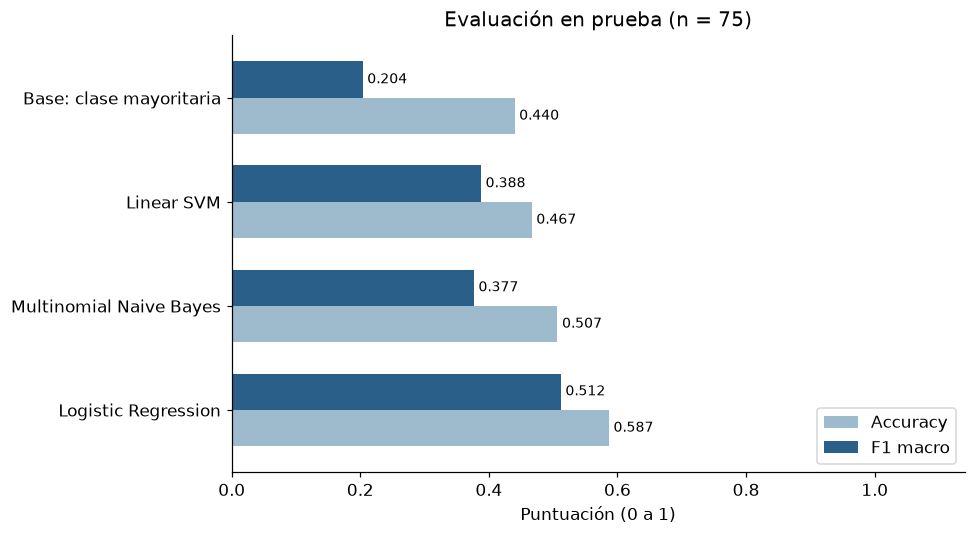

In [19]:
# Celda 19: tabla y gráfico de comparación
display(resultados_df.round(4))
grafico = resultados_df.set_index("Modelo")[["Accuracy", "F1_macro"]]
ax = grafico.plot.barh(color=["#9EBACD", "#295F88"], figsize=(9, 5), width=0.7)
ax.set_xlim(0, 1.14)
ax.set_xlabel("Puntuación (0 a 1)")
ax.set_ylabel("")
ax.set_title(f"Evaluación en prueba (n = {len(y_test):,})")
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.3f", padding=3, fontsize=9)
ax.legend(["Accuracy", "F1 macro"], loc="lower right")
ax.figure.tight_layout()
ax.figure.savefig(SALIDA / "comparacion_modelos.png", dpi=160)
plt.show()

### Celda 20. Guardar la evidencia

**Objetivo:** registrar qué datos, opciones y resultados produjo el experimento.

El primer `assert` comprueba que `mejor_nombre` todavía coincide con el mayor F1 macro de CV. `set_index("Modelo").loc[mejor_nombre]` localiza las métricas de prueba de ese modelo y las guarda en `metricas_final`.

El diccionario `resumen` reúne la fecha de ejecución en UTC, huellas de los archivos, versiones, semilla, exclusiones, idioma, fuente, predictor, etiqueta, agrupación, tamaños de conjuntos, configuración TF-IDF y resultados. La fecha describe cuándo se ejecutó el código; no es la fecha de los comentarios.

`json.dumps(..., indent=2, ensure_ascii=False)` convierte el diccionario en texto JSON legible y conserva los caracteres españoles. `write_text(..., encoding="utf-8")` lo escribe en `resultados/metricas.json`. `display(Markdown(...))` presenta las métricas principales usando los valores calculados.

**Salida:** un registro reproducible del experimento y un resumen del modelo seleccionado. El JSON guarda metadatos y resultados; **no guarda el modelo entrenado**. Al reiniciar el kernel, se deben ejecutar de nuevo las celdas de entrenamiento para utilizar la demostración.

In [20]:
# Celda 20: registrar el experimento
assert mejor_nombre == max(puntajes_cv, key=puntajes_cv.get)
metricas_final = resultados_df.set_index("Modelo").loc[mejor_nombre]
print("Modelo seleccionado:", mejor_nombre)
print("F1 macro CV:", round(puntajes_cv[mejor_nombre], 4))
print("F1 macro prueba:", round(metricas_final["F1_macro"], 4))
resumen = {
    "ejecutado_utc": datetime.now(timezone.utc).isoformat(), "sha256_dataset": sha256,
    "versiones": versiones, "semilla": SEMILLA, "auditoria": auditoria,
    "idioma": "es", "fuente": "Paper Reviews (UCI)",
    "etiqueta_origen": "orientation", "predictor": "text",
    "grupo": "articulo_id", "particion": "primer pliegue StratifiedGroupKFold(5, shuffle=True, random_state=42)",
    "articulos_entrenamiento": int(grupos_train.nunique()), "articulos_prueba": int(grupos_test.nunique()),
    "sha256_origen": procedencia["sha256_json_original"],
    "entrenamiento": len(y_train), "prueba": len(y_test), "folds": 5,
    "config_tfidf": config_tfidf, "modelo_seleccionado": mejor_nombre,
    "criterio_seleccion": "F1 macro CV exclusivamente en entrenamiento",
    "resultados_cv": cv_df.to_dict(orient="records"),
    "resultados_prueba": resultados_df.to_dict(orient="records"),
}
(SALIDA / "metricas.json").write_text(json.dumps(resumen, indent=2, ensure_ascii=False), encoding="utf-8")
display(Markdown(f"**{mejor_nombre}** obtiene F1 macro CV **{puntajes_cv[mejor_nombre]:.4f}**, "
                 f"Accuracy de prueba **{metricas_final['Accuracy']:.4f}** y F1 macro de prueba "
                 f"**{metricas_final['F1_macro']:.4f}**. Estos valores describen esta partición del corpus."))

Modelo seleccionado: Linear SVM
F1 macro CV: 0.5133
F1 macro prueba: 0.3877


**Linear SVM** obtiene F1 macro CV **0.5133**, Accuracy de prueba **0.4667** y F1 macro de prueba **0.3877**. Estos valores describen esta partición del corpus.

### Celda 21. Examinar el desempeño por clase

**Objetivo:** detectar errores que los promedios globales pueden ocultar.

`y_pred_final = predicciones[mejor_nombre]` recupera las predicciones de SVM ya calculadas. `classification_report(...)` las compara con `y_test` y muestra Precision, Recall, F1 y `support` para cada clase.

- `support` cuenta comentarios **reales** de cada clase en prueba: 33 negativos, 21 neutrales y 21 positivos. No cuenta cuántas veces predijo el modelo esa clase.
- `macro avg` asigna igual peso a las tres clases. `weighted avg` pondera por sus cantidades reales, por lo que las clases más frecuentes pesan más.
- `digits=4` controla los decimales mostrados; `output_dict=True` permite guardar el informe como datos en `reporte_clasificacion.csv`.

`predicciones_df` conserva el índice de cada fila, su clase real y su predicción. `.merge(...)` añade `articulo_id` y `evaluacion_id` para localizar errores; `.to_numpy()` utiliza los valores en el orden de la prueba. La tabla se guarda en `predicciones_prueba.csv`.

**Interpretación guardada:** neutral tiene F1 0,0606; se recupera solo 1 de sus 21 comentarios. El modelo distingue peor esa clase en esta prueba. `min(...)` identifica la clase de menor F1, pero el resultado no demuestra por sí solo la causa de sus errores.

In [21]:
# Celda 21: informe de clasificación
y_pred_final = predicciones[mejor_nombre]
print(classification_report(y_test, y_pred_final, labels=CLASES, digits=4, zero_division=0))
reporte = classification_report(y_test, y_pred_final, labels=CLASES, output_dict=True, zero_division=0)
pd.DataFrame(reporte).transpose().to_csv(SALIDA / "reporte_clasificacion.csv", index_label="clase")
predicciones_df = pd.DataFrame({"fila_modelado": X_test_text.index,
                                "real": y_test.to_numpy(), "predicho": y_pred_final})
predicciones_df = predicciones_df.merge(df[["articulo_id", "evaluacion_id"]], left_on="fila_modelado", right_index=True)
predicciones_df.to_csv(SALIDA / "predicciones_prueba.csv", index=False)
clase_dificil = min(CLASES, key=lambda c: reporte[c]["f1-score"])
display(Markdown(f"La clase con menor F1 en esta prueba es **{clase_dificil}** "
                 f"(**{reporte[clase_dificil]['f1-score']:.4f}**). "
                 "El resultado requiere inspeccionar errores; no establece por sí solo su causa."))

              precision    recall  f1-score   support

    negativo     0.5556    0.7576    0.6410        33
     neutral     0.0833    0.0476    0.0606        21
    positivo     0.5000    0.4286    0.4615        21

    accuracy                         0.4667        75
   macro avg     0.3796    0.4113    0.3877        75
weighted avg     0.4078    0.4667    0.4283        75



La clase con menor F1 en esta prueba es **neutral** (**0.0606**). El resultado requiere inspeccionar errores; no establece por sí solo su causa.

### Celda 22. Examinar la matriz de confusión

**Objetivo:** ver qué clases se confunden y comprobar la coherencia con Accuracy.

`confusion_matrix(..., labels=CLASES)` crea una tabla en el orden negativo, neutral y positivo. **Las filas son clases reales y las columnas son clases predichas.** La diagonal contiene aciertos; las demás posiciones contienen errores.

En la matriz guardada, la fila neutral es **[13, 1, 7]**: de 21 neutrales reales, 13 se predicen negativos, 1 neutral y 7 positivos. La diagonal completa suma **25 + 1 + 9 = 35** aciertos; `35 / 75 = 0,4667`, consistente con Accuracy.

Los `assert` comprueban que la matriz reúne todas las evaluaciones y que `np.trace(matriz) / matriz.sum()` coincide con Accuracy. `trace` suma la diagonal; `np.isclose(...)` compara decimales con tolerancia numérica.

El bucle dibuja dos vistas: conteos absolutos y proporciones por clase real. `normalize="true"` divide cada fila por su total; la diagonal normalizada corresponde al Recall de cada clase. Por ejemplo, `1 / 21 ≈ 0,0476` es el Recall neutral.

Finalmente, una copia de la matriz pone la diagonal a cero mediante `fill_diagonal(...)`. `argmax()` y `unravel_index(...)` localizan el error más frecuente: 13 neutrales predichos negativos. Compare también proporciones, porque los tamaños de las clases difieren.

**Archivos:** `matriz_confusion.png` y `matriz_confusion.csv`.

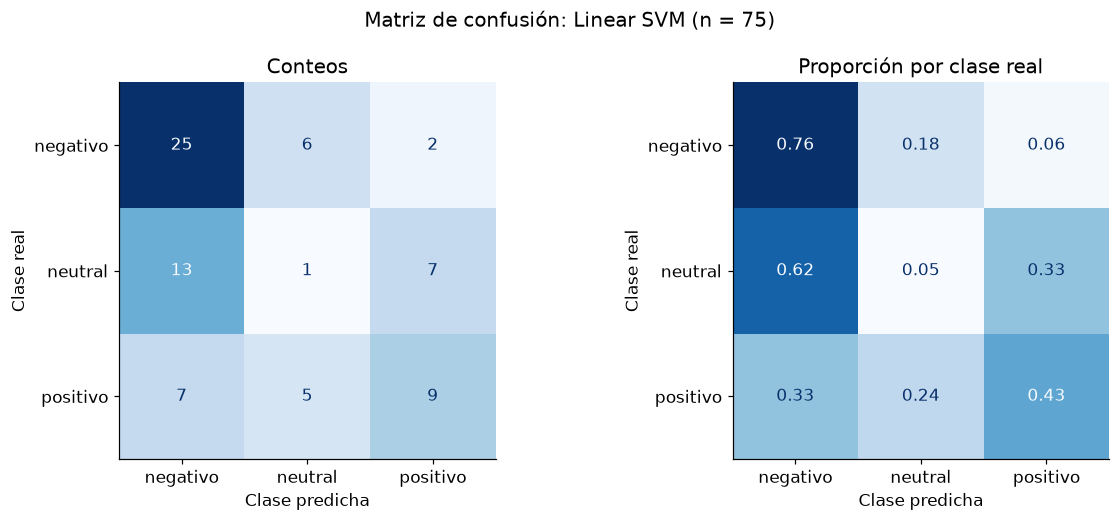

El mayor número absoluto de errores corresponde a evaluaciones **neutral** predichas como **negativo**: **13**. Compare también las proporciones, porque los soportes son distintos.

In [22]:
# Celda 22: matrices absoluta y normalizada
matriz = confusion_matrix(y_test, y_pred_final, labels=CLASES)
assert matriz.sum() == len(y_test)
assert np.isclose(np.trace(matriz) / matriz.sum(), metricas_final["Accuracy"])
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, normalizar, titulo, formato in [
    (axes[0], None, "Conteos", "d"), (axes[1], "true", "Proporción por clase real", ".2f")
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_final, labels=CLASES, normalize=normalizar,
        cmap="Blues", colorbar=False, values_format=formato, ax=ax,
    )
    ax.set_title(titulo)
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
fig.suptitle(f"Matriz de confusión: {mejor_nombre} (n = {len(y_test):,})")
fig.tight_layout()
fig.savefig(SALIDA / "matriz_confusion.png", dpi=160)
plt.show()
pd.DataFrame(matriz, index=CLASES, columns=CLASES).to_csv(SALIDA / "matriz_confusion.csv", index_label="real")
errores = matriz.copy()
np.fill_diagonal(errores, 0)
fila, columna = np.unravel_index(errores.argmax(), errores.shape)
display(Markdown(f"El mayor número absoluto de errores corresponde a evaluaciones **{CLASES[fila]}** "
                 f"predichas como **{CLASES[columna]}**: **{errores[fila, columna]}**. "
                 "Compare también las proporciones, porque los soportes son distintos."))

## 4.5 Explicación del código

El desarrollo sigue un recorrido: cargar y comprobar los datos, crear las etiquetas, limpiar el texto, separar los artículos, aprender la representación numérica, ajustar los modelos, evaluar y clasificar un comentario nuevo. **Cada una de las 23 celdas de código tiene una explicación inmediatamente encima**, con su objetivo, operaciones y lectura de las salidas. La numeración cuenta celdas de código, no bloques de texto ni el número de ejecuciones que Jupyter muestra entre corchetes.

### Guía para localizar cada paso

| Celda | Qué hace | Qué revisar |
| --- | --- | --- |
| 1 | Importa herramientas y configura rutas, semilla y gráficos. | Versiones y carpeta del proyecto. |
| 2 | Verifica el origen y carga el CSV español. | 388 evaluaciones, incluidas las vacías. |
| 3 | Comprueba columnas, tipos e identificadores. | Una fila por evaluación; varios comentarios por artículo. |
| 4 | Conserva texto, orientación e identificadores. | Solo el texto entra al clasificador. |
| 5 | Excluye textos vacíos y valida la orientación. | Seis exclusiones; quedan 382 evaluaciones. |
| 6 | Revisa duplicados exactos de texto y orientación. | Conteo de repeticiones. |
| 7 | Convierte orientación en negativo, neutral o positivo. | Tabla de correspondencia de las etiquetas. |
| 8 | Cuenta y dibuja la distribución de clases. | 172 negativos, 104 neutrales y 106 positivos. |
| 9 | Limpia español y revisa textos equivalentes. | Negaciones conservadas; exclusiones y conflictos registrados. |
| 10 | Define `X`, `y` y `grupos`. | Texto, respuesta esperada y artículo alineados. |
| 11 | Separa entrenamiento y prueba por artículo. | 307 y 75 evaluaciones; artículos sin solapamiento. |
| 12 | Configura palabras, bigramas y filtros TF-IDF. | Qué significa cada opción del vectorizador. |
| 13 | Demuestra `fit_transform` y `transform`. | Aprende solo con entrenamiento. |
| 14 | Inspecciona la representación numérica. | Filas, columnas, valores no negativos y vocabulario. |
| 15 | Crea regresión logística, Naive Bayes y SVM. | Cómo aprende cada algoritmo y sus opciones fijas. |
| 16 | Define hiperparámetros y cinco pliegues internos. | Validación agrupada dentro de entrenamiento. |
| 17 | Busca configuraciones y selecciona mediante CV. | SVM, `C=10`, F1 macro CV 0,5133. |
| 18 | Calcula métricas de prueba y la referencia mayoritaria. | Accuracy, Precision macro, Recall macro y F1 macro. |
| 19 | Muestra la comparación en tabla y gráfico. | Métricas de prueba sin cambiar la selección previa. |
| 20 | Guarda el registro del experimento. | `metricas.json`; no contiene el modelo entrenado. |
| 21 | Examina Precision, Recall, F1 y soporte por clase. | Neutral: F1 0,0606 y 1 de 21 recuperados. |
| 22 | Muestra conteos y proporciones de los errores. | Filas reales, columnas predichas y diagonal de aciertos. |
| 23 | Predice el sentimiento de `mi_evaluacion`. | Demostración de la práctica con el modelo ya entrenado. |

### Variables y operaciones que conviene reconocer

| Nombre u operación | Significado |
| --- | --- |
| `df_original` / `df` | Tabla cargada / tabla de trabajo que se prepara para modelar. |
| `auditoria` | Diccionario con cantidades y exclusiones del proceso. |
| `X_train_text` / `X_test_text` | Comentarios limpios de entrenamiento / prueba. |
| `y_train` / `y_test` | Etiquetas conocidas de entrenamiento / prueba. |
| `X_train` / `X_test` | Matrices TF-IDF didácticas; no son la entrada de GridSearchCV. |
| `mejores_modelos` / `mejor_modelo` | Candidatos reajustados / Pipeline seleccionado mediante CV. |
| `y_pred_final` | Predicciones del modelo seleccionado sobre la prueba. |
| `def` / `return` | Define una función / entrega su resultado al código que la utiliza. |
| `for` | Repite operaciones para cada elemento de una colección. |
| `assert` | Detiene la ejecución cuando no se cumple una comprobación. |
| `fit` | Aprende usando los datos proporcionados. |
| `transform` | Aplica una representación ya aprendida sin volver a ajustarla. |
| `fit_transform` | Aprende la representación y transforma los mismos datos. |
| `predict` | Utiliza un modelo entrenado para obtener etiquetas. |
| `display` / `print` / `to_csv` | Muestra tablas o texto enriquecido / imprime mensajes / guarda tablas. |

### Cómo explicar la práctica

Las etiquetas se conocen antes de entrenar: proceden de `orientation`. El modelo aprende una relación entre los términos del comentario y esas etiquetas. Los identificadores sirven para agrupar y revisar; no revelan el sentimiento al algoritmo.

Hay tres usos distintos de los datos: **entrenamiento** para aprender; **validación cruzada dentro del entrenamiento** para elegir opciones; y **prueba reservada** para medir el resultado de esa elección. Cada Pipeline aprende su TF-IDF dentro del pliegue correspondiente. Así la prueba y la validación no deciden el vocabulario con el que se entrenan los modelos.

Para exponer las métricas, use un ejemplo real de las salidas: SVM acierta 35 de 75 comentarios, por lo que Accuracy es 46,67 %. Su F1 macro de prueba es 0,3877. La matriz y el informe por clase muestran que neutral se reconoce peor. Estos resultados explican tanto el funcionamiento como los límites de la práctica; la demostración no garantiza que un comentario nuevo se clasifique correctamente.


### Celda 23. Demostración de la práctica

**Objetivo:** utilizar el clasificador entrenado con un comentario académico nuevo en español.

Primero, `requeridas` enumera `pd`, `limpiar_texto` y `mejor_modelo`. `globals()` consulta las variables disponibles en el kernel. Si falta alguna, el código lanza un `RuntimeError` con la instrucción de ejecutar todas las celdas desde el inicio. Un kernel reiniciado pierde las variables y el modelo que estaban en memoria.

La función `predecir_sentimiento(texto)` trabaja así:

1. `isinstance(texto, str)` exige texto y `.strip()` comprueba que no esté vacío. Si falla, devuelve un error claro mediante `ValueError`.
2. `limpiar_texto(texto)` aplica la misma limpieza que se utilizó con los datos de entrenamiento.
3. `mejor_modelo.named_steps["tfidf"]` accede al vectorizador entrenado. `.transform([texto_limpio])` representa el comentario sin aprender vocabulario nuevo. Los corchetes crean una lista con un único comentario.
4. `vector.nnz` cuenta sus valores distintos de cero. Si el texto quedó vacío o no contiene términos conocidos, se rechaza la entrada. Este control no detecta automáticamente el idioma ni garantiza una predicción fiable.
5. `mejor_modelo.predict([texto_limpio])[0]` transforma y clasifica mediante el `Pipeline` ya ajustado. `[0]` recupera la única predicción y `str(...)` la devuelve como etiqueta.

La lista `ejemplos` contiene tres frases redactadas para demostrar la función. La comprensión `[predecir_sentimiento(t) for t in ejemplos]` clasifica cada una y el DataFrame muestra sus salidas. No son el conjunto de prueba ni tienen etiquetas de evaluación asignadas en esta celda.

**Para probar:** cambie únicamente el texto entre comillas de `mi_evaluacion`, debajo de `CAMBIA ÚNICAMENTE EL TEXTO ENTRE COMILLAS`. Pulse **Shift + Enter** con esta celda seleccionada, después de ejecutar el notebook completo. Los `print` muestran su texto y el sentimiento predicho. No se vuelve a entrenar y no se muestra una probabilidad de confianza.

**Interpretación:** la etiqueta describe una predicción del tono del comentario. Puede equivocarse. Una predicción positiva no equivale a recomendar la aceptación del artículo.

In [23]:
# Celda 23: clasificar un comentario nuevo sobre un artículo científico
requeridas = ["pd", "limpiar_texto", "mejor_modelo"]
faltantes = [nombre for nombre in requeridas if nombre not in globals()]
if faltantes:
    raise RuntimeError("Primero ejecute todas las celdas desde el inicio. Falta: " + ", ".join(faltantes))
def predecir_sentimiento(texto):
    if not isinstance(texto, str) or not texto.strip():
        raise ValueError("Escriba una evaluación no vacía en español.")
    texto_limpio = limpiar_texto(texto)
    vector = mejor_modelo.named_steps["tfidf"].transform([texto_limpio])
    if not texto_limpio or vector.nnz == 0:
        raise ValueError("El comentario no contiene términos conocidos por el modelo.")
    return str(mejor_modelo.predict([texto_limpio])[0])
# Ejemplos redactados para la demo; no son el conjunto de prueba.
ejemplos = [
    "El artículo presenta una contribución original y relevante. La metodología es clara y los resultados están bien fundamentados.",
    "El artículo no presenta una contribución clara. La metodología es deficiente y los resultados no están justificados.",
    "El artículo describe el método y los resultados de un estudio sobre sistemas de información.",
]
display(pd.DataFrame({"evaluación": ejemplos,
                      "predicción": [predecir_sentimiento(t) for t in ejemplos]}))
# CAMBIA ÚNICAMENTE EL TEXTO ENTRE COMILLAS EN ESTA LÍNEA:
mi_evaluacion = "El artículo no explica la metodología y sus conclusiones no están justificadas."
print("Mi evaluación:", mi_evaluacion)
print("Sentimiento predicho:", predecir_sentimiento(mi_evaluacion))

,evaluación,predicción
0,El artículo presenta una contribución original y relevante. La metodología es clara y ...,negativo
1,El artículo no presenta una contribución clara. La metodología es deficiente y los res...,negativo
2,El artículo describe el método y los resultados de un estudio sobre sistemas de inform...,positivo


Mi evaluación: El artículo no explica la metodología y sus conclusiones no están justificadas.
Sentimiento predicho: negativo


### Interpretación y límites

El corpus es pequeño y contiene comentarios de 2010, 2013, 2014 y 2015. Las métricas describen esta partición y este dominio. No se realizó evaluación temporal ni por revisor, y no se garantiza el rendimiento en artículos actuales o de otras disciplinas. La agrupación mantiene separados los artículos; no detecta todas las paráfrasis entre artículos.

orientation refleja el sentimiento percibido por los anotadores. No equivale a evaluation ni a una decisión editorial. Agrupar cinco niveles en tres pierde intensidad. La limpieza pierde puntuación y cifras; TF-IDF no interpreta ironía ni contexto profundo. La demo ilustra predicciones, no valida por sí misma la calidad del modelo. No se calcularon intervalos de confianza ni pruebas de significación.

### Fuentes técnicas

- [Paper Reviews: esquema, procedencia y licencia CC BY 4.0](https://archive.ics.uci.edu/dataset/410/paper+reviews).
- [StratifiedGroupKFold: particiones con grupos separados](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html).
- [Pipeline y prevención de fuga de información](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).
- [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).
- [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [Métricas de clasificación: Precision, Recall, F1 y promedios](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).